<a href="https://oscar-defelice.github.io">
<img src="../../img/image.png" height="125" align="right" />
</a>

# TP 03-A — Naive Bayes — SOLUTION

**FOR INSTRUCTOR USE ONLY**

---

In [1]:
import re
import math
import warnings
from collections import Counter, defaultdict
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
sns.set_style("darkgrid")
SEED = 42
np.random.seed(SEED)
AG_NEWS_LABELS = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}

In [2]:
# ── Shared helpers (same as student notebook) ─────────────────────────────────

def preprocess_text(text: str) -> str:
    """Minimal 5-step text normalisation pipeline.

    Parameters
    ----------
    text : str
        Raw input string.

    Returns
    -------
    str
        Normalised string.
    """
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def load_ag_news(
    val_size: float = 0.1,
    seed: int = SEED,
) -> tuple[list[str], list[str], list[str], list[int], list[int], list[int]]:
    """Load AG News, preprocess, and split into train/val/test.

    Parameters
    ----------
    val_size : float
        Fraction of the training split to use as validation.
    seed : int
        Random seed.

    Returns
    -------
    tuple
        (train_texts, val_texts, test_texts, train_labels, val_labels, test_labels)
    """
    raw = load_dataset("ag_news")
    rng = np.random.default_rng(seed)

    train_texts_raw = [r["text"] for r in raw["train"]]
    train_labels_raw = [r["label"] for r in raw["train"]]
    test_texts = [preprocess_text(r["text"]) for r in raw["test"]]
    test_labels = [r["label"] for r in raw["test"]]

    n = len(train_texts_raw)
    idx = rng.permutation(n)
    split = int(n * (1 - val_size))
    train_idx, val_idx = idx[:split], idx[split:]

    train_texts  = [preprocess_text(train_texts_raw[i]) for i in train_idx]
    train_labels = [train_labels_raw[i]                 for i in train_idx]
    val_texts    = [preprocess_text(train_texts_raw[i]) for i in val_idx]
    val_labels   = [train_labels_raw[i]                 for i in val_idx]

    return train_texts, val_texts, test_texts, train_labels, val_labels, test_labels


def evaluate_classifier(
    y_true: list[int],
    y_pred: np.ndarray,
    label_names: list[str],
    title: str = "Evaluation",
) -> dict[str, float]:
    """Print classification report and plot confusion matrix.

    Parameters
    ----------
    y_true : list[int]
        Ground-truth labels.
    y_pred : np.ndarray
        Predicted labels.
    label_names : list[str]
        Human-readable class names in label order.
    title : str
        Title for the confusion matrix figure.

    Returns
    -------
    dict[str, float]
        Dictionary with 'accuracy' and 'macro_f1'.
    """
    report = classification_report(
        y_true, y_pred, target_names=label_names, output_dict=True
    )
    print(f"\n{'='*60}\n  {title}\n{'='*60}")
    print(classification_report(y_true, y_pred, target_names=label_names))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return {"accuracy": report["accuracy"], "macro_f1": report["macro avg"]["f1-score"]}


train_texts, val_texts, test_texts, train_labels, val_labels, test_labels = load_ag_news()
label_names = [AG_NEWS_LABELS[i + 1] for i in range(4)]
print(f"Train: {len(train_texts):,}  Val: {len(val_texts):,}  Test: {len(test_texts):,}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train: 108,000  Val: 12,000  Test: 7,600


---
## Part 2 — Naive Bayes from scratch


  Scratch NB — validation
              precision    recall  f1-score   support

       World       0.91      0.89      0.90      3027
      Sports       0.95      0.98      0.96      2961
    Business       0.88      0.85      0.87      3000
    Sci/Tech       0.87      0.90      0.88      3012

    accuracy                           0.90     12000
   macro avg       0.90      0.90      0.90     12000
weighted avg       0.90      0.90      0.90     12000



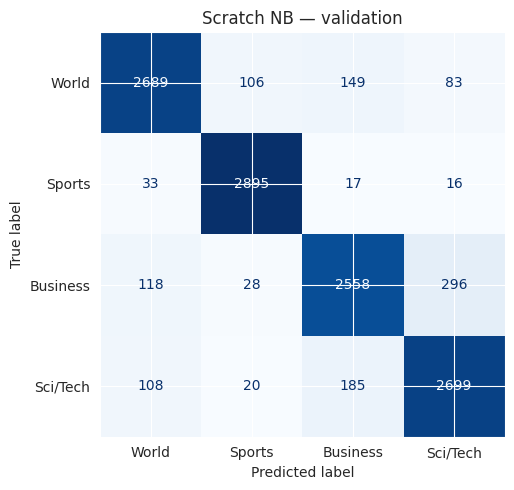

In [3]:
class NaiveBayesClassifier:
    """Multinomial Naive Bayes text classifier with Laplace smoothing.

    Parameters
    ----------
    alpha : float
        Laplace smoothing parameter. Must be > 0.

    Attributes
    ----------
    classes_ : list[int]
        Sorted list of unique class labels seen during fit.
    log_priors_ : dict[int, float]
        log P(c) for each class.
    log_likelihoods_ : dict[int, dict[str, float]]
        log P(w | c) for each class and word.
    vocab_ : set[str]
        Vocabulary seen during training.
    _log_unk_ : dict[int, float]
        log-probability of an unseen word for each class.
    """

    def __init__(self, alpha: float = 1.0) -> None:
        self.alpha = alpha
        self.classes_: list[int] = []
        self.log_priors_: dict[int, float] = {}
        self.log_likelihoods_: dict[int, dict[str, float]] = {}
        self.vocab_: set[str] = set()
        self._log_unk_: dict[int, float] = {}

    def fit(self, texts: list[str], labels: list[int]) -> "NaiveBayesClassifier":
        """Estimate priors and likelihoods from training data.

        Parameters
        ----------
        texts : list[str]
            Pre-tokenised (whitespace-split) training documents.
        labels : list[int]
            Integer class labels.

        Returns
        -------
        NaiveBayesClassifier
            Fitted classifier.
        """
        n_docs = len(labels)
        label_counter = Counter(labels)
        self.classes_ = sorted(label_counter.keys())

        # ── Priors ───────────────────────────────────────────────────────────
        self.log_priors_ = {
            c: math.log(count / n_docs)
            for c, count in label_counter.items()
        }

        # ── Word counts per class ─────────────────────────────────────────────
        word_counts: dict[int, Counter] = {c: Counter() for c in self.classes_}
        for text, label in zip(texts, labels):
            word_counts[label].update(text.split())

        # ── Build global vocabulary ───────────────────────────────────────────
        self.vocab_ = set()
        for counter in word_counts.values():
            self.vocab_.update(counter.keys())
        vocab_size = len(self.vocab_)

        # ── Likelihoods with Laplace smoothing ────────────────────────────────
        for c in self.classes_:
            total = sum(word_counts[c].values()) + self.alpha * vocab_size
            self.log_likelihoods_[c] = {
                w: math.log((cnt + self.alpha) / total)
                for w, cnt in word_counts[c].items()
            }
            # Probability for unseen words (count = 0 → add alpha)
            self._log_unk_[c] = math.log(self.alpha / total)

        return self

    def _score(self, text: str) -> dict[int, float]:
        """Compute log P(c) + sum_i log P(w_i | c) for each class.

        Parameters
        ----------
        text : str
            A single whitespace-tokenised document.

        Returns
        -------
        dict[int, float]
            Mapping from class label to log-score.
        """
        tokens = text.split()
        scores: dict[int, float] = {}
        for c in self.classes_:
            score = self.log_priors_[c]
            ll = self.log_likelihoods_[c]
            unk = self._log_unk_[c]
            for token in tokens:
                score += ll.get(token, unk)
            scores[c] = score
        return scores

    def predict(self, texts: list[str]) -> np.ndarray:
        """Predict the most probable class for each document.

        Parameters
        ----------
        texts : list[str]
            Documents to classify.

        Returns
        -------
        np.ndarray of shape (len(texts),)
            Predicted integer class labels.
        """
        return np.array([
            max(self._score(text), key=self._score(text).get)
            for text in texts
        ])

    def top_features(
        self, class_label: int, n: int = 10
    ) -> list[tuple[str, float]]:
        """Return the n words with the highest log-likelihood for a given class.

        Parameters
        ----------
        class_label : int
            Class to inspect.
        n : int
            Number of top features to return.

        Returns
        -------
        list[tuple[str, float]]
            (word, log_P(w|c)) pairs sorted descending.
        """
        ll = self.log_likelihoods_[class_label]
        return sorted(ll.items(), key=lambda x: x[1], reverse=True)[:n]


# ── NOTE FOR INSTRUCTOR ───────────────────────────────────────────────────────
# predict() calls _score() twice. A clean fix:
#   scores = self._score(text)
#   return max(scores, key=scores.get)
# Students who spot this and fix it should get a bonus.

clf_scratch = NaiveBayesClassifier(alpha=1.0)
clf_scratch.fit(train_texts, train_labels)
val_pred_scratch = clf_scratch.predict(val_texts)
results_scratch = evaluate_classifier(
    val_labels, val_pred_scratch, label_names, title="Scratch NB — validation"
)
# Expected: macro F1 ≈ 0.82–0.84


  sklearn NB (count, α=1) — validation
              precision    recall  f1-score   support

       World       0.92      0.89      0.90      3027
      Sports       0.95      0.98      0.96      2961
    Business       0.88      0.85      0.87      3000
    Sci/Tech       0.87      0.89      0.88      3012

    accuracy                           0.90     12000
   macro avg       0.90      0.90      0.90     12000
weighted avg       0.90      0.90      0.90     12000



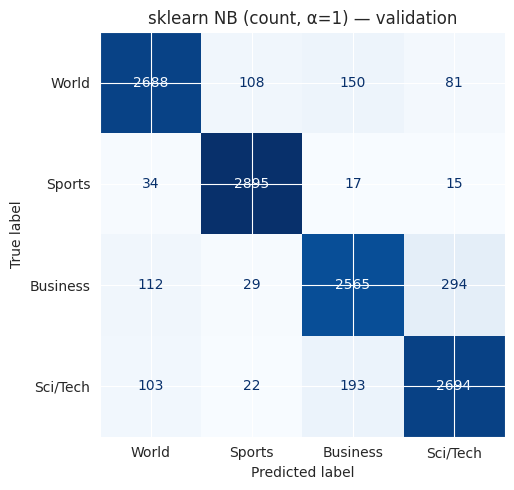

In [4]:
# ── Part 3.1 — sklearn pipeline ───────────────────────────────────────────────

def build_nb_pipeline(
    alpha: float = 1.0,
    vectorizer: str = "count",
    max_features: int | None = 50_000,
    ngram_range: tuple[int, int] = (1, 1),
) -> Pipeline:
    """Build a sklearn Pipeline: vectoriser → MultinomialNB.

    Parameters
    ----------
    alpha : float
        Laplace smoothing parameter.
    vectorizer : {'count', 'tfidf'}
        Which vectoriser to use.
    max_features : int or None
        Maximum vocabulary size.
    ngram_range : tuple[int, int]
        N-gram range passed to the vectoriser.

    Returns
    -------
    Pipeline
        Unfitted sklearn Pipeline.

    Raises
    ------
    ValueError
        If vectorizer is not 'count' or 'tfidf'.
    """
    if vectorizer == "count":
        vec = CountVectorizer(max_features=max_features, ngram_range=ngram_range)
    elif vectorizer == "tfidf":
        vec = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
    else:
        raise ValueError(f"vectorizer must be 'count' or 'tfidf', got '{vectorizer}'")
    return Pipeline([("vec", vec), ("nb", MultinomialNB(alpha=alpha))])


pipe_nb = build_nb_pipeline(alpha=1.0, vectorizer="count")
pipe_nb.fit(train_texts, train_labels)
val_pred_nb = pipe_nb.predict(val_texts)
results_nb = evaluate_classifier(
    val_labels, val_pred_nb, label_names, title="sklearn NB (count, α=1) — validation"
)
# Expected: macro F1 ≈ 0.84–0.86 (slightly higher than scratch due to sklearn's tokeniser)

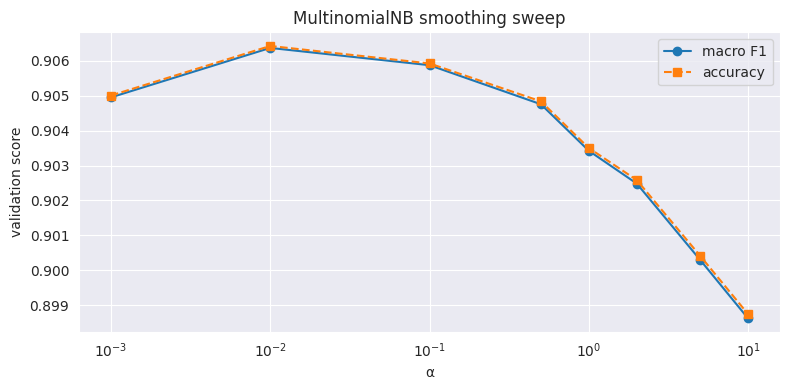

Best α = 0.01


In [5]:
# ── Part 3.2 — smoothing sweep ────────────────────────────────────────────────

def smoothing_sweep(
    alphas: Iterable[float],
    train_texts: list[str],
    train_labels: list[int],
    val_texts: list[str],
    val_labels: list[int],
) -> pd.DataFrame:
    """Evaluate MultinomialNB for a range of smoothing values.

    Parameters
    ----------
    alphas : Iterable[float]
        Values of α to evaluate.
    train_texts, train_labels, val_texts, val_labels : lists
        Data splits.

    Returns
    -------
    pd.DataFrame
        Columns: ['alpha', 'val_accuracy', 'val_macro_f1']
    """
    rows = []
    for a in alphas:
        pipe = build_nb_pipeline(alpha=a, vectorizer="count")
        pipe.fit(train_texts, train_labels)
        preds = pipe.predict(val_texts)
        report = classification_report(val_labels, preds, output_dict=True)
        rows.append({
            "alpha": a,
            "val_accuracy": report["accuracy"],
            "val_macro_f1": report["macro avg"]["f1-score"],
        })
    return pd.DataFrame(rows)


alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
sweep_df = smoothing_sweep(alphas, train_texts, train_labels, val_texts, val_labels)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(sweep_df["alpha"], sweep_df["val_macro_f1"], marker="o", label="macro F1")
ax.semilogx(sweep_df["alpha"], sweep_df["val_accuracy"], marker="s", linestyle="--", label="accuracy")
ax.set_xlabel("α")
ax.set_ylabel("validation score")
ax.set_title("MultinomialNB smoothing sweep")
ax.legend()
plt.tight_layout()
plt.show()

best_alpha = sweep_df.loc[sweep_df["val_macro_f1"].idxmax(), "alpha"]
print(f"Best α = {best_alpha}")
# Expected: α ≈ 0.1–0.5 is typically best. Very small → overfit to rare words.
# Very large → all words get similar probs, model ignores vocabulary.


World:
     word     log_p    score
     sadr -7.837335 7.943036
    hamas -7.872691 7.916519
  falluja -8.061713 7.774752
  taliban -8.271737 7.617234
  zarqawi -8.447179 7.485653
    qaida -8.503529 7.443390
   arafat -6.741223 7.439293
    mosul -8.547979 7.410053
    sunni -8.547979 7.410053
militants -6.868377 7.242976

Sports:
        word     log_p    score
   preseason -8.523322 7.434710
      knicks -8.624197 7.359053
   cavaliers -8.768149 7.251089
     broncos -8.768149 7.251089
    phillies -8.794293 7.231481
    coaching -8.794293 7.231481
diamondbacks -8.884313 7.163966
  linebacker -8.891585 7.158512
         mvp -8.928761 7.130630
  outfielder -8.991277 7.083743

Business:
      word     log_p    score
 fullquote -5.750743 9.507764
 quickinfo -6.443887 8.987906
      aspx -6.443887 8.987906
treasuries -8.564106 7.397742
     ovitz -9.000795 7.070225
  parmalat -9.192670 6.926320
bombardier -9.382693 6.783802
       ual -9.382693 6.783802
       dal -9.455005 6.729568
 

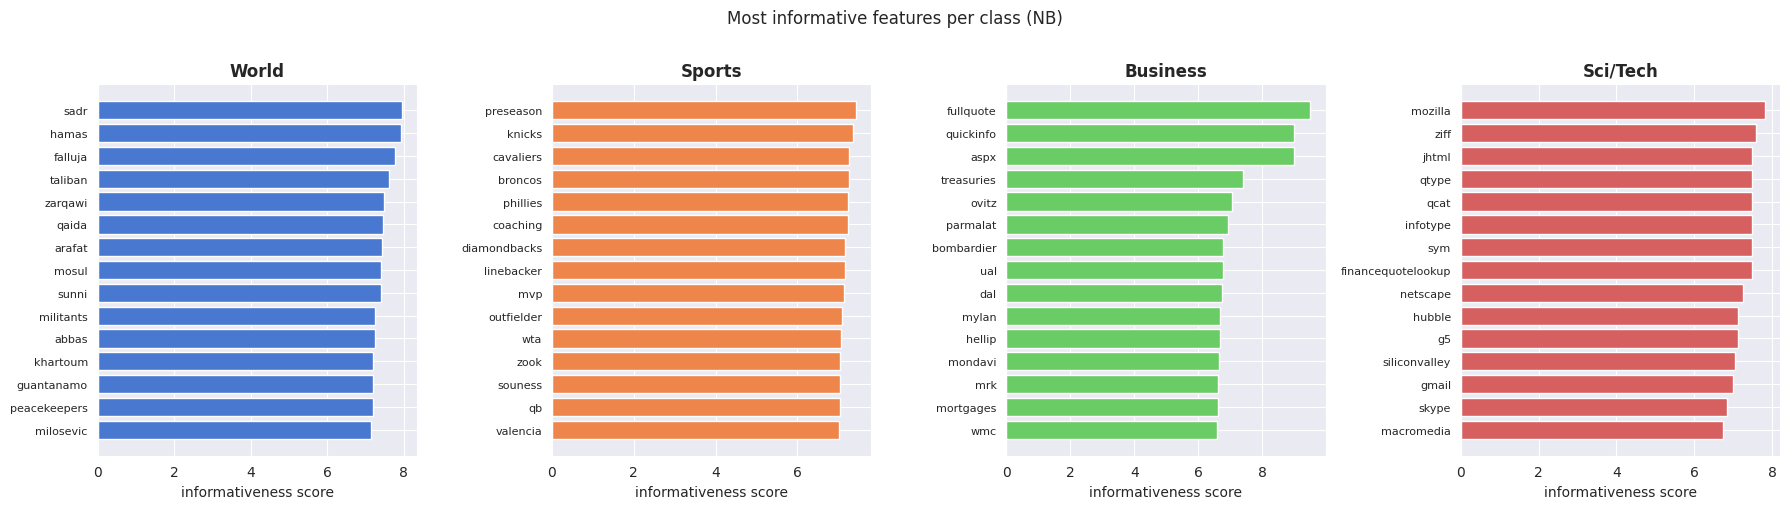

In [6]:
# ── Part 4 — Most informative features ────────────────────────────────────────

def most_informative_features(
    pipeline: Pipeline,
    label_names: list[str],
    n: int = 20,
) -> dict[str, pd.DataFrame]:
    """Extract the n most informative features per class from a fitted NB pipeline.

    Score for word w in class c: log P(w | c) − mean over c' of log P(w | c').

    Parameters
    ----------
    pipeline : Pipeline
        Fitted sklearn Pipeline (vectoriser + MultinomialNB).
    label_names : list[str]
        Human-readable class names in label order.
    n : int
        Number of top features per class.

    Returns
    -------
    dict[str, pd.DataFrame]
        class_name → DataFrame['word', 'log_p', 'score']
    """
    vec = pipeline[0]
    nb  = pipeline[1]
    vocab = vec.get_feature_names_out()            # shape: (vocab_size,)
    log_probs = nb.feature_log_prob_               # shape: (n_classes, vocab_size)
    mean_log_probs = log_probs.mean(axis=0)        # shape: (vocab_size,)
    scores = log_probs - mean_log_probs            # shape: (n_classes, vocab_size)

    result: dict[str, pd.DataFrame] = {}
    for idx, name in enumerate(label_names):
        top_idx = np.argsort(scores[idx])[::-1][:n]
        result[name] = pd.DataFrame({
            "word":  vocab[top_idx],
            "log_p": log_probs[idx, top_idx],
            "score": scores[idx, top_idx],
        })
    return result


def plot_informative_features(features: dict[str, pd.DataFrame], n_plot: int = 15) -> None:
    """Bar plot of the most informative features per class.

    Parameters
    ----------
    features : dict[str, pd.DataFrame]
        Output of `most_informative_features`.
    n_plot : int
        Number of features to display per class.
    """
    n_classes = len(features)
    fig, axes = plt.subplots(1, n_classes, figsize=(4.5 * n_classes, 5))
    palette = sns.color_palette("muted", n_classes)
    for ax, (name, df), colour in zip(axes, features.items(), palette):
        top = df.head(n_plot)
        ax.barh(top["word"][::-1], top["score"][::-1], color=colour)
        ax.set_title(name, fontweight="bold")
        ax.set_xlabel("informativeness score")
        ax.tick_params(axis="y", labelsize=8)
    plt.suptitle("Most informative features per class (NB)", y=1.01)
    plt.tight_layout()
    plt.show()


pipe_best = build_nb_pipeline(alpha=best_alpha, vectorizer="count")
pipe_best.fit(train_texts, train_labels)
features = most_informative_features(pipe_best, label_names)
for name, df in features.items():
    print(f"\n{name}:")
    print(df.head(10).to_string(index=False))
plot_informative_features(features)

In [7]:
# ── Part 5.1 — BoW vs TF-IDF ──────────────────────────────────────────────────

def compare_vectorizers(
    train_texts: list[str],
    train_labels: list[int],
    val_texts: list[str],
    val_labels: list[int],
    alpha: float = 1.0,
) -> pd.DataFrame:
    """Compare CountVectorizer vs TfidfVectorizer for MultinomialNB.

    Parameters
    ----------
    train_texts, train_labels, val_texts, val_labels : lists
        Data splits.
    alpha : float
        Smoothing parameter.

    Returns
    -------
    pd.DataFrame
        Columns: ['vectorizer', 'val_accuracy', 'val_macro_f1']
    """
    rows = []
    for name in ["count", "tfidf"]:
        pipe = build_nb_pipeline(alpha=alpha, vectorizer=name)
        pipe.fit(train_texts, train_labels)
        preds = pipe.predict(val_texts)
        report = classification_report(val_labels, preds, output_dict=True)
        rows.append({
            "vectorizer": name,
            "val_accuracy": report["accuracy"],
            "val_macro_f1": report["macro avg"]["f1-score"],
        })
    return pd.DataFrame(rows)


print(compare_vectorizers(
    train_texts, train_labels, val_texts, val_labels, alpha=best_alpha
).to_string(index=False))
# TF-IDF typically gains +1-2% F1 by downweighting stop words

vectorizer  val_accuracy  val_macro_f1
     count      0.906417      0.906361
     tfidf      0.907083      0.907100


In [8]:
# ── Part 5.2 — Bigrams ────────────────────────────────────────────────────────

def ngram_sweep(
    train_texts: list[str],
    train_labels: list[int],
    val_texts: list[str],
    val_labels: list[int],
    alpha: float = 1.0,
) -> pd.DataFrame:
    """Compare unigram vs unigram+bigram features for MultinomialNB.

    Parameters
    ----------
    train_texts, train_labels, val_texts, val_labels : lists
        Data splits.
    alpha : float
        Smoothing parameter.

    Returns
    -------
    pd.DataFrame
        Columns: ['features', 'vocab_size', 'val_accuracy', 'val_macro_f1']
    """
    configs = [
        ("unigrams",         (1, 1)),
        ("unigrams+bigrams", (1, 2)),
    ]
    rows = []
    for name, ngram_range in configs:
        pipe = build_nb_pipeline(alpha=alpha, vectorizer="tfidf", ngram_range=ngram_range)
        pipe.fit(train_texts, train_labels)
        preds = pipe.predict(val_texts)
        report = classification_report(val_labels, preds, output_dict=True)
        vocab_size = len(pipe[0].get_feature_names_out())
        rows.append({
            "features":     name,
            "vocab_size":   vocab_size,
            "val_accuracy": report["accuracy"],
            "val_macro_f1": report["macro avg"]["f1-score"],
        })
    return pd.DataFrame(rows)


print(ngram_sweep(
    train_texts, train_labels, val_texts, val_labels, alpha=best_alpha
).to_string(index=False))
# Bigrams typically add +0.5-1.5% at the cost of 5–10x more features

        features  vocab_size  val_accuracy  val_macro_f1
        unigrams       50000      0.907083      0.907100
unigrams+bigrams       50000      0.904917      0.904871


In [9]:
# ── Part 7 — Error analysis ───────────────────────────────────────────────────

def sample_errors(
    texts: list[str],
    y_true: list[int],
    y_pred: np.ndarray,
    label_names: list[str],
    n: int = 10,
    seed: int = SEED,
) -> pd.DataFrame:
    """Sample n misclassified documents.

    Parameters
    ----------
    texts : list[str]
        Input documents.
    y_true : list[int]
        Ground-truth labels.
    y_pred : np.ndarray
        Predicted labels.
    label_names : list[str]
        Human-readable class names.
    n : int
        Number of errors to sample.
    seed : int
        Random seed.

    Returns
    -------
    pd.DataFrame
        Columns: ['text', 'true_label', 'predicted_label']
    """
    rng = np.random.default_rng(seed)
    y_true_arr = np.array(y_true)
    error_idx = np.where(y_true_arr != y_pred)[0]
    sampled = rng.choice(error_idx, size=min(n, len(error_idx)), replace=False)

    return pd.DataFrame({
        "text":            [texts[i][:150] for i in sampled],
        "true_label":      [label_names[y_true_arr[i]] for i in sampled],
        "predicted_label": [label_names[y_pred[i]]     for i in sampled],
    })


errors = sample_errors(val_texts, val_labels, val_pred_nb, label_names)
pd.set_option("display.max_colwidth", 120)
print(errors.to_string(index=False))

# ── INSTRUCTOR NOTES ──────────────────────────────────────────────────────────
# Common patterns to highlight:
# 1. Business ↔ Sci/Tech: tech company news (Apple, Google earnings) touches both
# 2. World ↔ Politics: political news often covers world events
# 3. Sports business: transfer fees, stadium contracts → Business or Sports?
# These ambiguities are genuine and NB cannot resolve them without context.

                                                                                                                                                  text true_label predicted_label
intel clouded by back to school fears intel corp 39 s intc o quote profile research upcoming mid quarter report will be closely watched for signs of w   Sci/Tech        Business
it s football not footloose in the nfl it used to be the object of the game was to get into the end zone now the object of the game is to get into the     Sports        Sci/Tech
voluntary flu vaccine rationing urged washington federal health officials are urging doctors to restrict flu shots to those patients at highest risk f      World        Business
ali boxing needs us commission muhammad ali asked congress yesterday to create a us boxing commission saying oversight by the federal government is ne     Sports           World
microsoft seeks video game winner with halo 2 the anticipated release of halo 2 is the latest and perhaps the 


  Best NB (TF-IDF + bigrams) — TEST
              precision    recall  f1-score   support

       World       0.92      0.89      0.90      1900
      Sports       0.95      0.98      0.97      1900
    Business       0.87      0.85      0.86      1900
    Sci/Tech       0.86      0.89      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



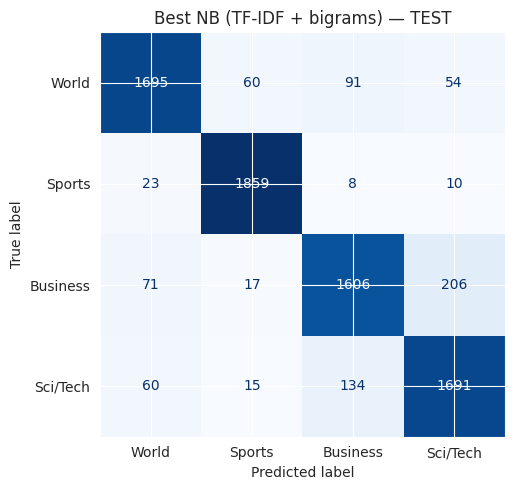


Test accuracy: 0.9014
Test macro F1: 0.9012


In [10]:
# ── Final test set evaluation ─────────────────────────────────────────────────
# Best config: TF-IDF + unigrams+bigrams + best_alpha
pipe_final = build_nb_pipeline(alpha=best_alpha, vectorizer="tfidf", ngram_range=(1, 2))
pipe_final.fit(train_texts, train_labels)
test_pred = pipe_final.predict(test_texts)
results_test = evaluate_classifier(
    test_labels, test_pred, label_names, title="Best NB (TF-IDF + bigrams) — TEST"
)
# Expected: macro F1 ≈ 0.87–0.89 on test set
print(f"\nTest accuracy: {results_test['accuracy']:.4f}")
print(f"Test macro F1: {results_test['macro_f1']:.4f}")